#### Imports:

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#### Functions:

Method      |  N  | Shock Pos  |  S     |  Error
--------------------------------------------------
upwind        100   0.7727      -1.7273     3.2273


conservative  100   0.8030      -1.6970     3.1970


upwind        200   0.7814      -1.7186     3.2186


conservative  200   0.8015      -1.6985     3.1985




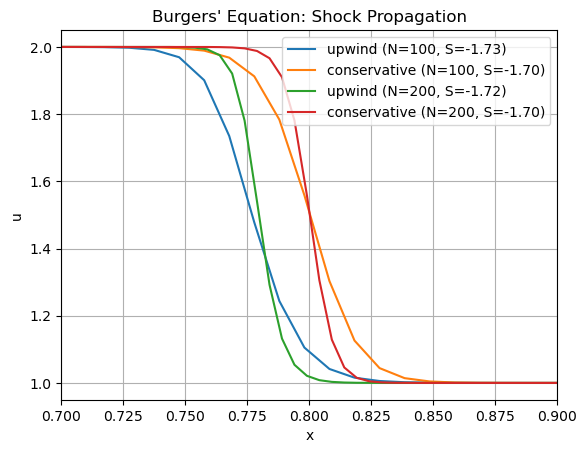

In [105]:
def initial_conditions(x):
    return np.where(x < 0.5, 2.0, 1.0)

def compute_timestep(u, dx, cfl=0.5):
    return cfl * dx / np.max(u)

def upwind_step(u, dx, dt):
    unew = u.copy()
    for i in range(1, len(u)):
        unew[i] = u[i] - dt / dx * u[i] * (u[i] - u[i-1])
    return unew

def conservative_step(u, dx, dt):
    unew = u.copy()
    for i in range(1, len(u)):
        flux_i = 0.5 * u[i]**2
        flux_im1 = 0.5 * u[i-1]**2
        unew[i] = u[i] - dt / dx * (flux_i - flux_im1)
    return unew

def run_simulation(N, tmax=0.2, method='upwind'):
    x = np.linspace(0, 1, N)
    dx = x[1] - x[0]
    u = initial_conditions(x)
    u_init = u.copy()
    t = 0.0

    while t < tmax:
        dt = compute_timestep(u, dx)
        if t + dt > tmax:
            dt = tmax - t
        if method == 'upwind':
            u = upwind_step(u, dx, dt)
        elif method == 'conservative':
            u = conservative_step(u, dx, dt)
        t += dt

    # Estimate shock position
      # Estimate shock position (maximum drop in u)
    shock_index = np.argmin(np.diff(u))
    shock_position = 0.5 * (x[shock_index] + x[shock_index + 1])
    return x, u, shock_position

def plot_results():
    tmax = 0.2
    true_shock_speed = 1.5

    print("Method      |  N  | Shock Pos  |  S     |  Error")
    print("--------------------------------------------------")
    #print('\n')
    
    for N in [100, 200]:
        for method in ['upwind', 'conservative']:
            x, u_final, shock_x = run_simulation(N, tmax=tmax , method=method)
            S = shock_x - 0.5 / tmax  # since shock starts at 0
            error = abs(S - true_shock_speed)

            print(f"{method:<13} {N:<5} {shock_x:.4f}      {S:.4f}     {error:.4f}")            
            plt.plot(x, u_final, label=f"{method} (N={N}, S={S:.2f})")
            print('\n')

    plt.title("Burgers' Equation: Shock Propagation")
    plt.xlabel("x")
    plt.ylabel("u")
    plt.xlim(0.7,0.9)
    plt.legend()
    plt.grid()
    plt.show()

plot_results()

#### Explaination:

The Burgers' Equation is:
$$ S = \frac{1}{2} (u_L + u_R)$$

And the Initial Conditions are:

$$ u(x,0) = 
\Biggl\{ \, \huge^{2 \quad if \,\, x \,\, < \,\, 0.5} _{1 \quad if \,\, x \,\, \ge \,\, 0.5} $$

$$ \Rightarrow S = \frac{1}{2}(2+1) = 1.5$$

What was solved should be the expected speed. (This means I also went back into the code and adjusted it. (┬┬﹏┬┬) But I don't remember what I did before...)

## Maybe I can animate this! (ﾉ◕ヮ◕)ﾉ*:･ﾟ✧

This does not work well, or maybe it does, I'm not that good at this stuff..

#### Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

#### Functions(and other stuff?)

In [ ]:
def initial_conditions(x):
    return np.where(x < 0.5, 2.0, 1.0)

def compute_timestep(u, dx, cfl=0.5):
    return cfl * dx / np.max(u)

def upwind_step(u, dx, dt):
    unew = u.copy()
    for i in range(1, len(u)):
        unew[i] = u[i] - dt / dx * u[i] * (u[i] - u[i-1])
    return unew

def conservative_step(u, dx, dt):
    unew = u.copy()
    for i in range(1, len(u)):
        flux_i = 0.5 * u[i]**2
        flux_im1 = 0.5 * u[i-1]**2
        unew[i] = u[i] - dt / dx * (flux_i - flux_im1)
    return unew

def run_simulation_frames(N, tmax=0.2, method='upwind'):
    x = np.linspace(0, 1, N)
    dx = x[1] - x[0]
    u = initial_conditions(x)
    t = 0.0
    frames = [u.copy()]
    times = [t]

    while t < tmax:
        dt = compute_timestep(u, dx)
        if t + dt > tmax:
            dt = tmax - t
        if method == 'upwind':
            u = upwind_step(u, dx, dt)
        elif method == 'conservative':
            u = conservative_step(u, dx, dt)
        t += dt
        frames.append(u.copy())
        times.append(t)
    return x, frames, times

# Run both methods
N = 200
tmax = 0.2
x, upwind_frames, upwind_times = run_simulation_frames(N, tmax, 'upwind')
_, conservative_frames, _ = run_simulation_frames(N, tmax, 'conservative')

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
lines = [axs[0].plot([], [], lw=2)[0], axs[1].plot([], [], lw=2)[0]]
time_text = fig.text(0.5, 0.92, '', ha='center', fontsize=12)

for ax, title in zip(axs, ['Upwind Method', 'Conservative Method']):
    ax.set_xlim(0, 1)
    ax.set_ylim(0.8, 2.2)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.grid(True)

def init():
    for line in lines:
        line.set_data([], [])
    time_text.set_text('')
    return lines + [time_text]

def animate(i):
    lines[0].set_data(x, upwind_frames[i])
    lines[1].set_data(x, conservative_frames[i])
    time_text.set_text(f"Time = {upwind_times[i]:.3f} s")
    return lines + [time_text]

ani = animation.FuncAnimation(fig, animate, init_func=init,
                              frames=len(upwind_frames), interval=50, blit=True)

# Save the animation as a GIF
ani.save("shock_propagation_with_time.gif", writer='pillow', fps=120)

plt.tight_layout()
plt.show()

# ↑ That was a mistake, I should not have done that, it is just moving to the right. ಠ╭╮ಠ